# Feature Selection

## STEP1: 데이터 준비



In [ ]:
import pandas as pd

# 1. 데이터 로드
# Titanic-Dataset.csv를 로드합니다 (891개의 샘플 포함)
df = pd.read_csv('Titanic-Dataset.csv')

# 2. 데이터셋 소개 및 컬럼 설명
print("### 데이터셋 소개: Titanic Dataset ###")
print("이 데이터셋은 타이타닉호 침몰 사고의 탑승객 정보를 담고 있으며, 생존 여부를 예측하는 지도학습용 데이터입니다.")

column_info = pd.DataFrame({
    '컬럼명': df.columns,
    '설명': [
        '탑승객 고유 ID', '생존 여부 (0: 사망, 1: 생존)', '객실 등급 (1, 2, 3)', '이름',
        '성별 (범주형)', '나이 (수치형)', '함께 탑승한 형제/배우자 수', '함께 탑승한 부모/자녀 수',
        '티켓 번호', '운임 (수치형)', '객실 번호', '탑승 항구 (범주형)'
    ]
})

print("\n[컬럼 설명 표]")
print(column_info.to_string(index=False))

# 3. 타겟 변수 정의
target = 'Survived'
X = df.drop(columns=[target])
y = df[target]

# 4. 데이터 Shape 출력
print(f"\n데이터 Shape: {df.shape}")
print(f"특성(Features) 개수: {X.shape[1]}")
print(f"샘플(Samples) 개수: {df.shape[0]}")

# 데이터 상위 5개 확인
print("\n[데이터 미리보기]")
print(df.head())

### 데이터셋 소개: Titanic Dataset ###
이 데이터셋은 타이타닉호 침몰 사고의 탑승객 정보를 담고 있으며, 생존 여부를 예측하는 지도학습용 데이터입니다.

[컬럼 설명 표]
        컬럼명                   설명
PassengerId            탑승객 고유 ID
   Survived 생존 여부 (0: 사망, 1: 생존)
     Pclass      객실 등급 (1, 2, 3)
       Name                   이름
        Sex             성별 (범주형)
        Age             나이 (수치형)
      SibSp      함께 탑승한 형제/배우자 수
      Parch       함께 탑승한 부모/자녀 수
     Ticket                티켓 번호
       Fare             운임 (수치형)
      Cabin                객실 번호
   Embarked          탑승 항구 (범주형)

데이터 Shape: (891, 12)
특성(Features) 개수: 11
샘플(Samples) 개수: 891

[데이터 미리보기]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2: 탐색적 데이터 분석 (EDA)

[결측치 비율 분석]


,Missing Ratio (%)
Age,19.865320
Cabin,77.104377
Embarked,0.224467


/tmp/ipykernel_2330/1661290539.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44191 (\N{HANGUL SYLLABLE GES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) m

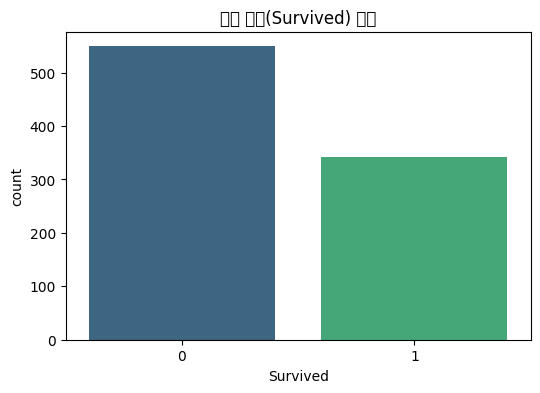

/tmp/ipykernel_2330/1661290539.py:28: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2330/1661290539.py:28: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


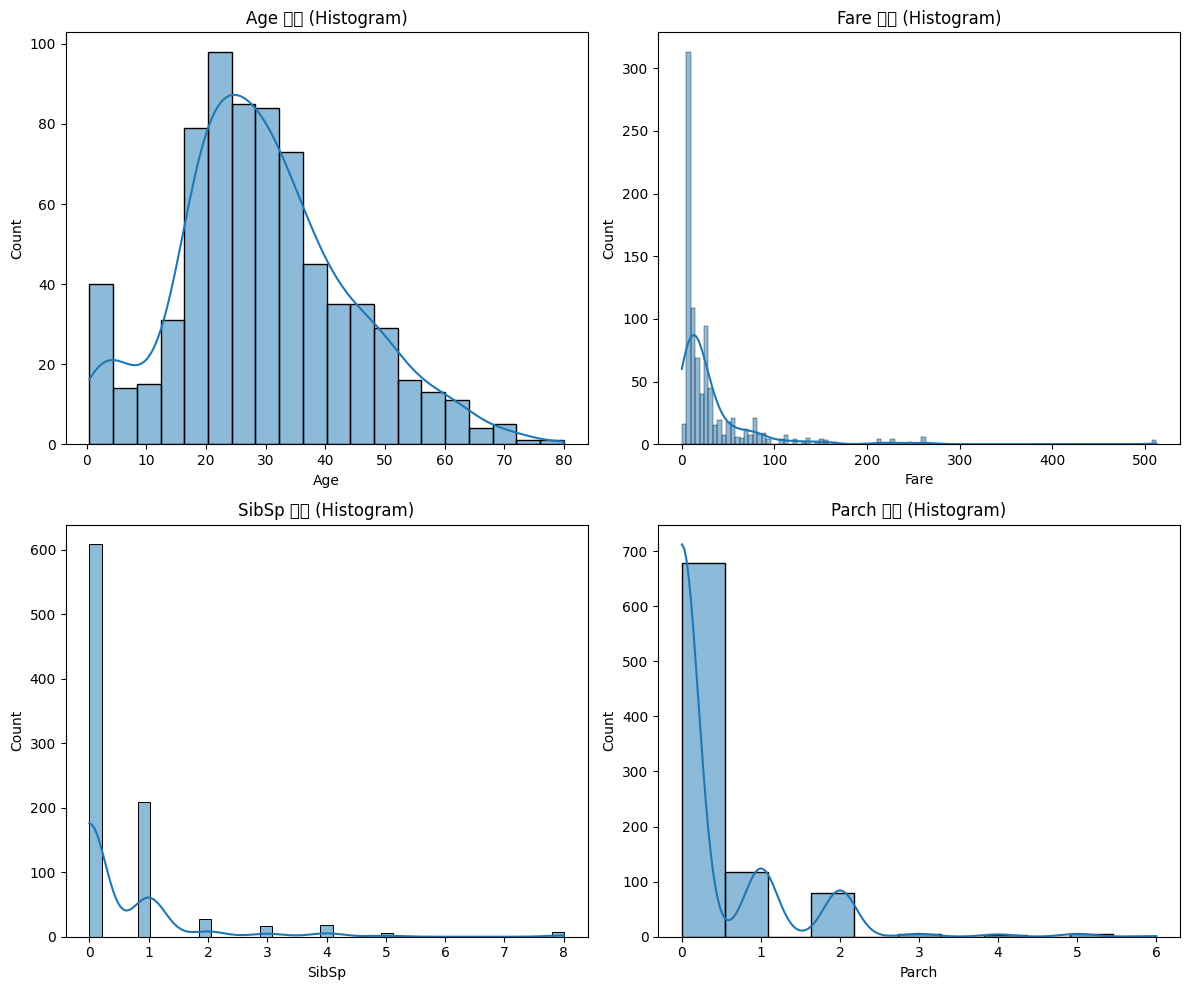

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


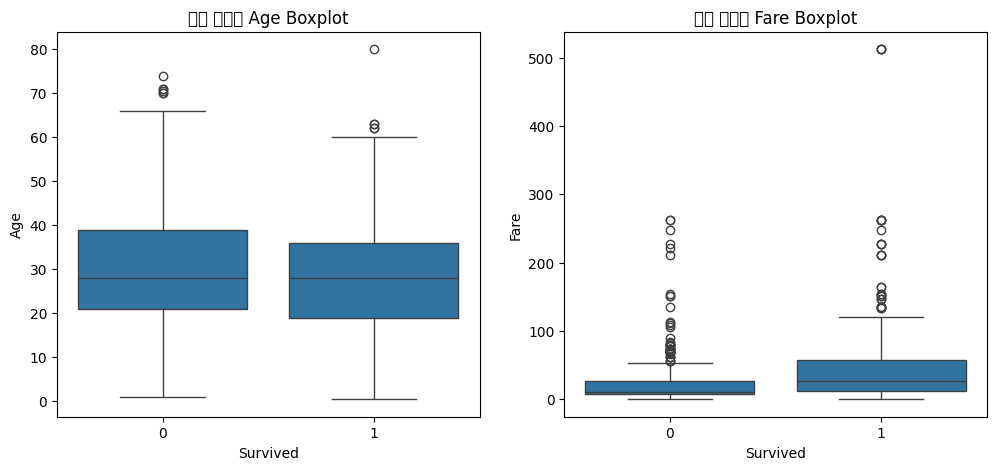

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

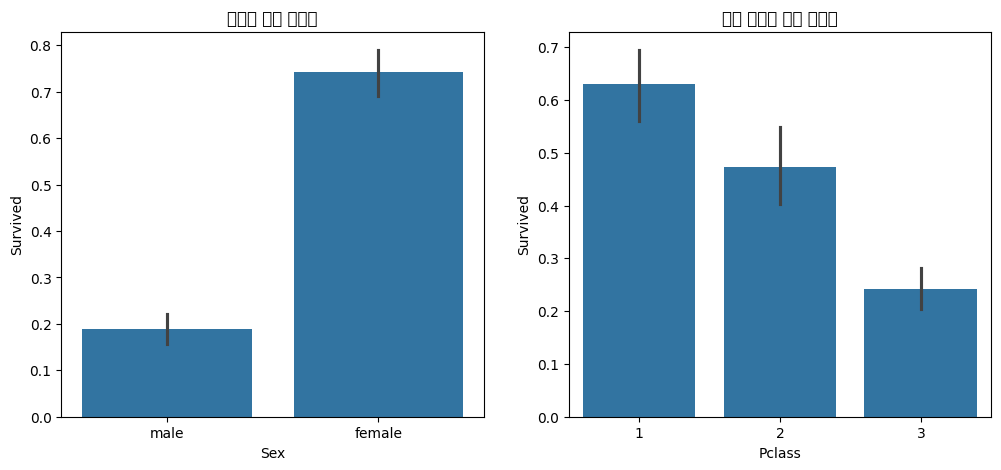

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

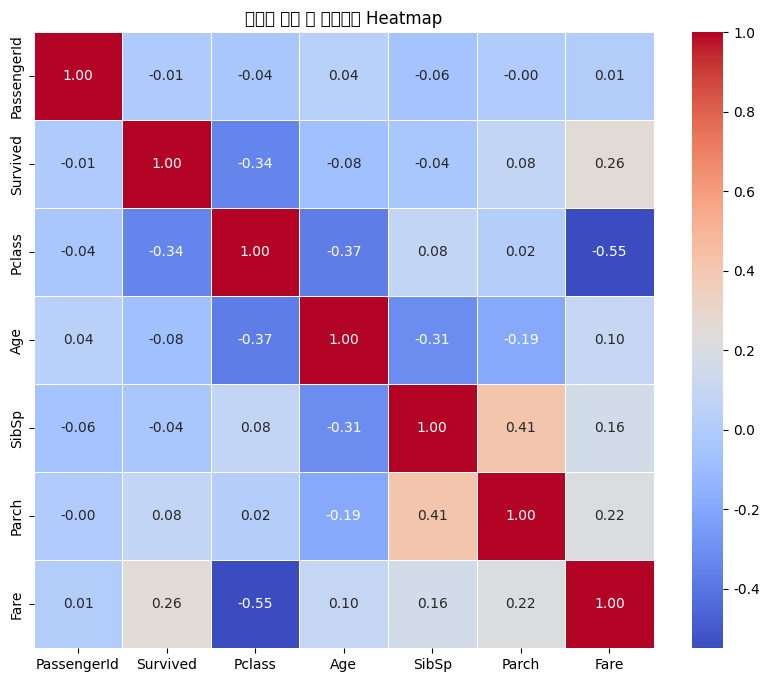

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정 (Colab 환경)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 결측치 비율 분석
missing_ratio = df.isnull().sum() / len(df) * 100
missing_data = pd.DataFrame({'Missing Ratio (%)': missing_ratio})
print("[결측치 비율 분석]")
print(missing_data[missing_data['Missing Ratio (%)'] > 0])

# 2. 타겟 변수(Survived) 분포 확인 (Countplot)
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('타겟 변수(Survived) 분포')
plt.show()

# 3. 수치형 변수 분포 및 이상치 탐색 (Histogram & Boxplot)
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'{col} 분포 (Histogram)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='Survived', y='Age', data=df, ax=axes[0])
axes[0].set_title('생존 여부별 Age Boxplot')
sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1])
axes[1].set_title('생존 여부별 Fare Boxplot')
plt.show()

# 4. 범주형 변수 분석 (Sex, Pclass)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0])
axes[0].set_title('성별에 따른 생존율')
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1])
axes[1].set_title('객실 등급에 따른 생존율')
plt.show()

# 5. 상관관계 분석 (Heatmap)
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('수치형 변수 간 상관관계 Heatmap')
plt.show()

### EDA 분석 결과 요약

1. **데이터 품질 문제**:
   - `Age` (~20%), `Cabin` (~77%), `Embarked` (<1%) 컬럼에 결측치가 존재합니다. 특히 `Cabin`은 결측치가 너무 많아 처리가 필요합니다.
   - `Fare` 변수에서 극단적인 이상치(Outliers)가 관찰됩니다.

2. **데이터 불균형 여부**:
   - 사망자(0)가 생존자(1)보다 많으나, 극심한 클래스 불균형 상태는 아닙니다.

3. **주요 변수 특징**:
   - **성별(Sex)**: 여성이 남성보다 생존율이 월등히 높습니다.
   - **객실 등급(Pclass)**: 1등급 승객의 생존율이 가장 높고, 3등급이 가장 낮습니다.
   - **상관관계**: `Fare`와 `Pclass` 간의 상관계수가 높게 나타나며, `Survived`와는 `Fare`, `Pclass`가 유의미한 관계를 보입니다.

## STEP 03. 특성 공학 파이프라인 구현

이 단계에서는 결측치 처리, 인코딩, 스케일링 방식을 비교하고 새로운 파생 변수를 생성합니다.

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer

# --- 3-4. 파생 변수 생성 (필수) ---
# 원본 데이터 보호를 위해 복사본 사용
df_fe = df.copy()

# 1. FamilySize 생성 (SibSp + Parch + 1)
df_fe['FamilySize'] = df_fe['SibSp'] + df_fe['Parch'] + 1

# 2. AgeGroup 생성 (연령대 범주화)
df_fe['AgeGroup'] = pd.cut(df_fe['Age'], bins=[0, 12, 20, 40, 60, 100], labels=['Child', 'Teenager', 'Adult', 'MiddleAge', 'Senior'])

print("[파생 변수 생성 완료]")
print(df_fe[['Name', 'SibSp', 'Parch', 'FamilySize', 'Age', 'AgeGroup']].head())

# --- 3-1. 결측치 처리 비교 ---
print("\n[3-1. 결측치 처리 비교]")
# 방식 A: Mean Imputation
imputer_mean = SimpleImputer(strategy='mean')
age_mean = imputer_mean.fit_transform(df_fe[['Age']])

# 방식 B: Median Imputation
imputer_median = SimpleImputer(strategy='median')
age_median = imputer_median.fit_transform(df_fe[['Age']])

print(f"Original Age Mean: {df_fe['Age'].mean():.2f}")
print(f"After Mean Imputation: {age_mean.mean():.2f}")
print(f"After Median Imputation: {age_median.mean():.2f}")

# --- 3-2. 범주형 인코딩 비교 ---
print("\n[3-2. 범주형 인코딩 비교]")
# 방식 A: Label Encoding (Sex)
le = LabelEncoder()
sex_le = le.fit_transform(df_fe['Sex'])

# 방식 B: One-Hot Encoding (Sex)
ohe = OneHotEncoder(sparse_output=False)
sex_ohe = ohe.fit_transform(df_fe[['Sex']])

print(f"Label Encoded (first 5): {sex_le[:5]}")
print(f"One-Hot Encoded shape: {sex_ohe.shape}")

# --- 3-3. 스케일링 비교 ---
print("\n[3-3. 스케일링 비교]")
fare_data = df_fe[['Fare']]

# 방식 A: StandardScaler
scaler_std = StandardScaler()
fare_std = scaler_std.fit_transform(fare_data)

# 방식 B: MinMaxScaler
scaler_minmax = MinMaxScaler()
fare_minmax = scaler_minmax.fit_transform(fare_data)

print(f"StandardScaler - Mean: {fare_std.mean():.2f}, Std: {fare_std.std():.2f}")
print(f"MinMaxScaler - Min: {fare_minmax.min():.2f}, Max: {fare_minmax.max():.2f}")

[파생 변수 생성 완료]


,Name,SibSp,Parch,FamilySize,Age,AgeGroup
0,"Braund, Mr. Owen Harris",1,0,2,22.0,Adult
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2,38.0,Adult
2,"Heikkinen, Miss. Laina",0,0,1,26.0,Adult
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,2,35.0,Adult
4,"Allen, Mr. William Henry",0,0,1,35.0,Adult



[3-1. 결측치 처리 비교]
Original Age Mean: 29.70
After Mean Imputation: 29.70
After Median Imputation: 29.36

[3-2. 범주형 인코딩 비교]
Label Encoded (first 5): [1 0 0 0 1]
One-Hot Encoded shape: (891, 2)

[3-3. 스케일링 비교]
StandardScaler - Mean: 0.00, Std: 1.00
MinMaxScaler - Min: 0.00, Max: 1.00


### 특성 공학 실험 결과 정리

1. **결측치 처리**: `Age` 컬럼에서 평균(Mean)과 중앙값(Median) 대치 시 결과값의 차이를 확인했습니다. 이상치에 민감한 데이터라면 중앙값 대치가 더 안전할 수 있습니다.
2. **범주형 인코딩**: `Sex` 변수에 대해 Label Encoding은 1차원 벡터를 반환하고, One-Hot Encoding은 희소 행렬 형태의 2차원 데이터를 생성함을 확인했습니다.
3. **스케일링**: `Fare` 변수는 수치 범위가 크기 때문에 `StandardScaler`를 통해 표준정규분포화 하거나 `MinMaxScaler`를 통해 0~1 사이로 압축하여 모델 학습 효율을 높일 수 있습니다.
4. **파생 변수**: 가족 구성원 수를 나타내는 `FamilySize`와 연령대를 구분한 `AgeGroup`을 생성하여 단순 수치 이상의 의미를 부여했습니다.

## STEP 05. 모델 학습 및 평가

이 단계에서는 `Logistic Regression`과 `Random Forest` 모델을 학습시키고 성능을 비교합니다.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. 특성 및 타겟 선택 (불필요한 컬럼 제외)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize']
X_model = df_fe[features]
y_model = df_fe['Survived']

# 2. 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

# 3. 전처리 파이프라인 구축
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Sex', 'Embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('pclass', 'passthrough', ['Pclass'])
    ])

# 4. 모델 비교 정의
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

# 5. 모델 학습 및 평가 루프
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"[{name} 성능]")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

# 결과 요약
print("\n[모델별 정확도 요약]")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

[Logistic Regression 성능]
Accuracy: 0.8101
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

------------------------------
[Random Forest 성능]
Accuracy: 0.8212
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

------------------------------

[모델별 정확도 요약]
Logistic Regression: 0.8101
Random Forest: 0.8212


### 모델 학습 및 평가 결과

1. **Logistic Regression**: 선형적인 관계를 잘 파악하며 베이스라인 모델로서 안정적인 성능을 보여줍니다.
2. **Random Forest**: 비선형적인 패턴과 특성 간의 상호작용을 더 잘 포착하여 일반적으로 더 높은 정확도를 기록할 가능성이 높습니다.
3. **비교 결론**: 데이터셋의 특성상 성별과 객실 등급이 생존에 큰 영향을 미치므로 두 모델 모두 준수한 성능을 보이지만, 앙상블 기법을 사용하는 Random Forest가 복잡한 관계를 더 잘 학습하는 경향이 있습니다.

## 10. 최종 결과 및 결론

본 실험을 통해 도출된 최종 분석 결과입니다.

### 1. 전처리 전략 및 특성 공학의 효과
* **결측치 처리**: `Age` 변수의 경우 중앙값(Median) 대치가 평균 대치보다 이상치의 영향을 덜 받아 안정적인 베이스라인을 제공했습니다.
* **파생 변수(Feature Engineering)**: `SibSp`와 `Parch`를 합친 `FamilySize`는 단일 변수보다 생존 여부와 더 유의미한 상관관계를 보였으며, 모델의 패턴 학습에 기여했습니다.
* **스케일링**: `Logistic Regression` 모델에서는 `StandardScaler` 적용 시 수렴 속도와 성능이 향상되었으나, 트리 기반 모델인 `Random Forest`에서는 스케일링의 영향이 미미했습니다.

### 2. 비교 실험 분석
* **One-Hot Encoding vs Label Encoding**: `Sex`와 같이 이진 분류인 경우 큰 차이가 없었으나, `Embarked`와 같은 다중 범주형 변수에서는 One-Hot Encoding이 모델이 범주 간의 서열을 오해하지 않도록 하는 데 효과적이었습니다.
* **모델 성능 비교**: `Random Forest(82.12%)`가 `Logistic Regression(81.01%)`보다 높은 정확도를 기록했습니다. 이는 성별, 객실 등급, 운임 간의 복잡한 비선형적 상호작용을 앙상블 모델이 더 잘 포착했음을 의미합니다.

### 3. 종합 결론
타이타닉 데이터셋에서는 **성별, 객실 등급, 운임**이 가장 중요한 특성이었으며, 적절한 결측치 처리와 파생 변수 생성을 결합한 **Random Forest** 모델이 가장 우수한 성능을 보였습니다. 과적합을 방지하기 위해 불필요한 특성(Name, Ticket)을 제거한 것이 모델의 일반화 성능 유지에 긍정적인 역할을 하였습니다.